In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Column names for Wisconsin Diagnostic Breast Cancer Dataset

columns = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv(
    "wdbc.data",
    header=None,
    names=columns
)

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (569, 32)

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  

In [4]:
# Separate features and target

X = df.drop(
    columns=["id", "diagnosis"]
)

y = df["diagnosis"]

# Convert diagnosis:
# M = 0 (Malignant)
# B = 1 (Benign)

y = y.map({
    "M": 0,
    "B": 1
})

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features: (569, 30)
Target: (569,)

Target Distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [5]:
print("Dataset Information:")
X.info()

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nClass Distribution:")
print(y.value_counts())

print("\nStatistical Summary:")
print(X.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoot

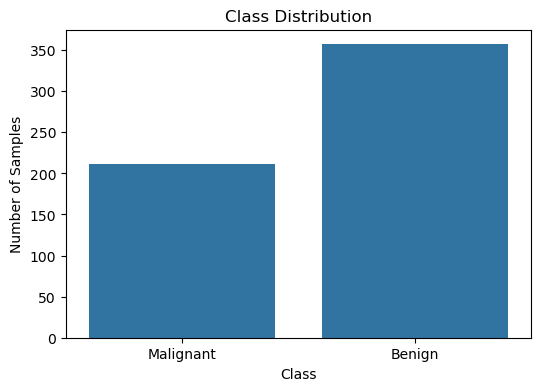

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.show()

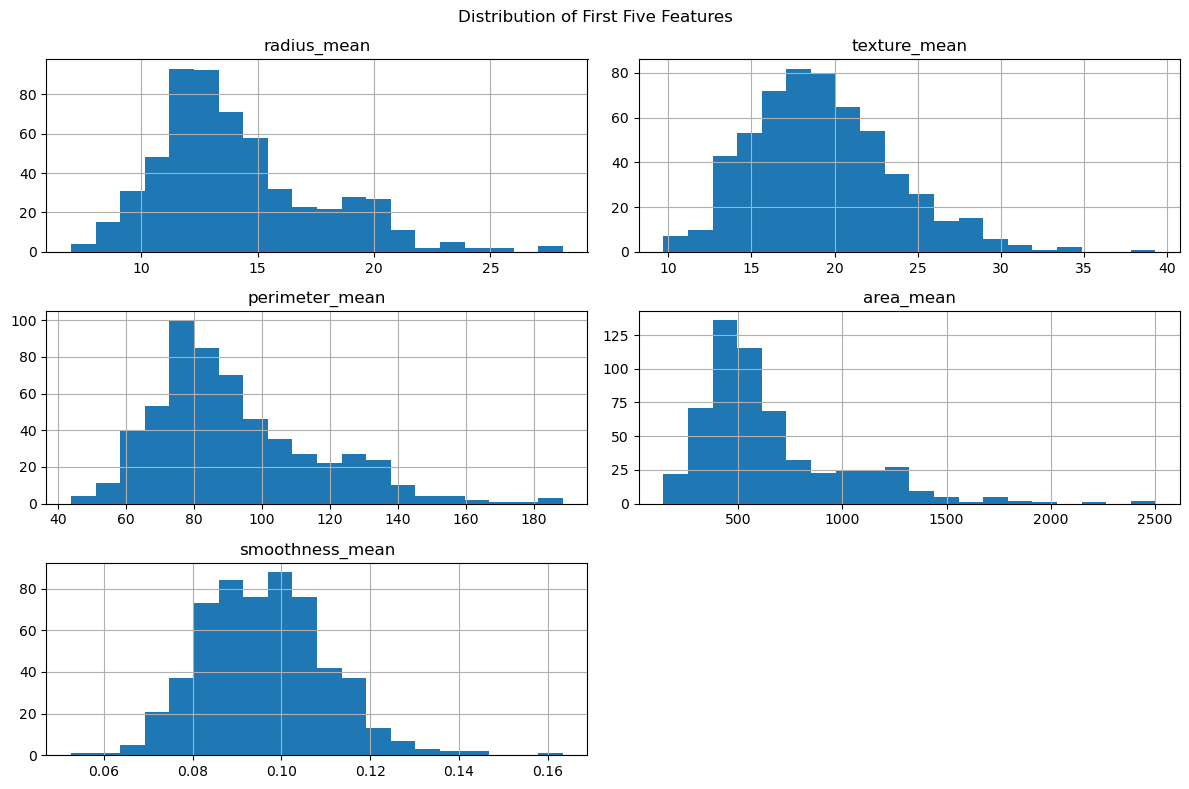

In [7]:
X.iloc[:, :5].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of First Five Features")

plt.tight_layout()

plt.show()

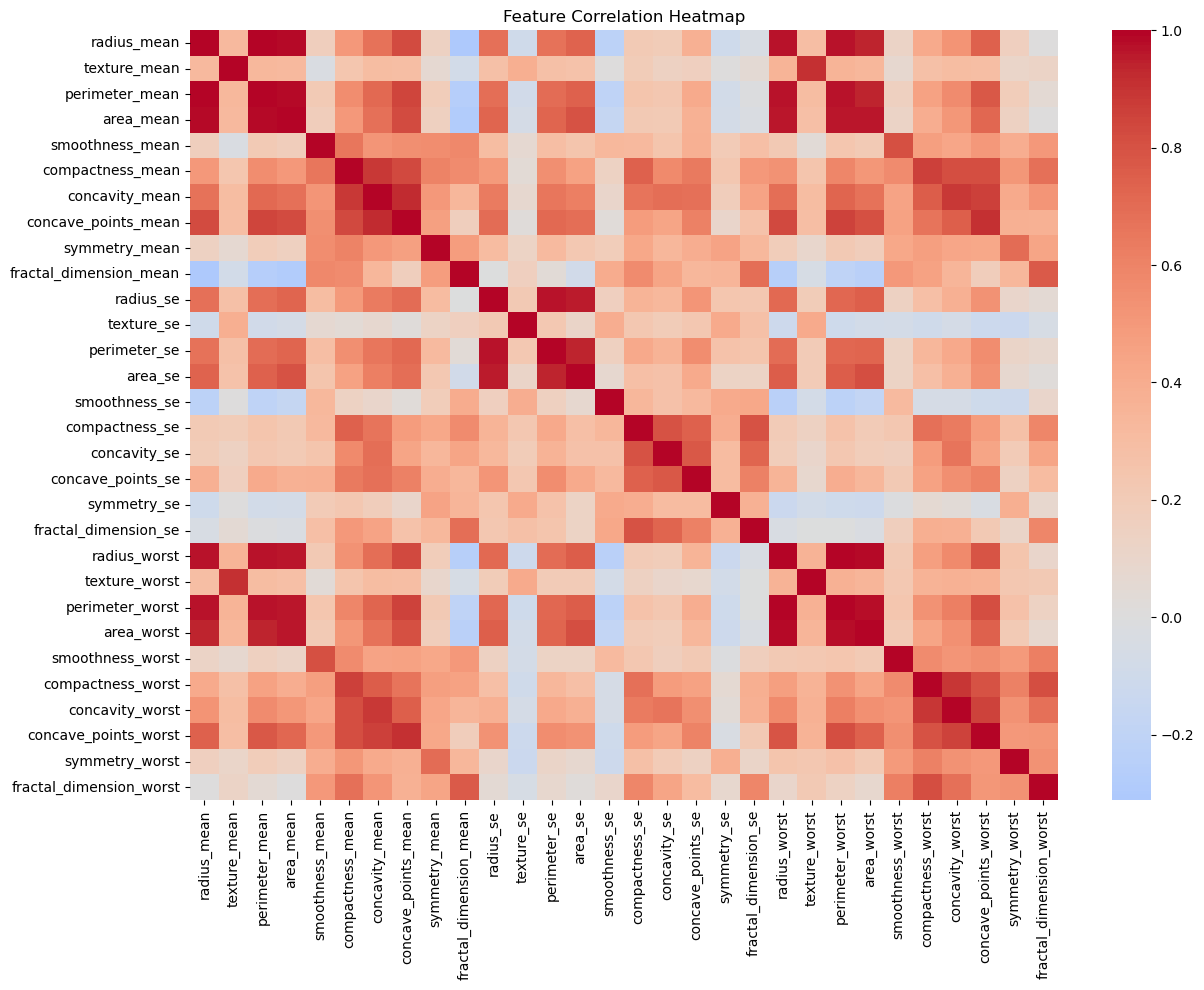

In [8]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [11]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    n_estimators=10,
    max_samples=0.8,
    max_features=1.0,
    random_state=42
)

bagging.fit(
    X_train,
    y_train
)

bagging_pred = bagging.predict(
    X_test
)

print("Bagging model trained successfully.")

Bagging model trained successfully.


In [12]:
bagging_params = {
    "n_estimators": [3, 5, 10, 20],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

bagging_grid = GridSearchCV(
    estimator=bagging,
    param_grid=bagging_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bagging_grid.fit(
    X_train,
    y_train
)

print("Best Bagging Parameters:")
print(bagging_grid.best_params_)

print("\nBest CV Accuracy:")
print(bagging_grid.best_score_)

Best Bagging Parameters:
{'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 20}

Best CV Accuracy:
0.9582417582417582


In [25]:
# Get the best Bagging model

best_bagging = bagging_grid.best_estimator_

# Train the best model

best_bagging.fit(
    X_train,
    y_train
)

# Predict on test data

bagging_pred = best_bagging.predict(
    X_test
)

# Probability for ROC-AUC

bagging_prob = best_bagging.predict_proba(
    X_test
)[:, 1]

print("Best Bagging model trained successfully.")

Best Bagging model trained successfully.


In [26]:
bagging_results = []

for n in [3, 5, 10, 20]:

    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            random_state=42
        ),
        n_estimators=n,
        max_samples=0.8,
        max_features=1.0,
        random_state=42
    )

    accuracy = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    bagging_results.append([
        n,
        0.8,
        accuracy * 100,
        f1 * 100
    ])


bagging_table = pd.DataFrame(
    bagging_results,
    columns=[
        "n_estimators",
        "max_samples",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score (%)"
    ]
)

print(bagging_table)

   n_estimators  max_samples  Avg CV Accuracy (%)  Avg CV F1 Score (%)
0             3          0.8            93.626374            94.928284
1             5          0.8            95.164835            96.163885
2            10          0.8            94.945055            95.961740
3            20          0.8            94.505495            95.616460


In [27]:
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    random_state=42
)

adaboost_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

adaboost_grid = GridSearchCV(
    estimator=adaboost,
    param_grid=adaboost_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

adaboost_grid.fit(
    X_train,
    y_train
)

print("Best AdaBoost Parameters:")
print(adaboost_grid.best_params_)

print("\nBest CV Accuracy:")
print(adaboost_grid.best_score_)

Best AdaBoost Parameters:
{'learning_rate': 0.5, 'n_estimators': 100}

Best CV Accuracy:
0.9780219780219781


In [15]:
best_adaboost = adaboost_grid.best_estimator_

best_adaboost.fit(
    X_train,
    y_train
)

adaboost_pred = best_adaboost.predict(
    X_test
)

adaboost_prob = best_adaboost.predict_proba(
    X_test
)[:, 1]

print("AdaBoost prediction completed.")

AdaBoost prediction completed.


In [16]:
gradient = GradientBoostingClassifier(
    random_state=42
)

gradient_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [1, 2, 3]
}

gradient_grid = GridSearchCV(
    estimator=gradient,
    param_grid=gradient_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gradient_grid.fit(
    X_train,
    y_train
)

print("Best Gradient Boosting Parameters:")
print(gradient_grid.best_params_)

print("\nBest CV Accuracy:")
print(gradient_grid.best_score_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 100}

Best CV Accuracy:
0.9802197802197803


In [17]:
best_gradient = gradient_grid.best_estimator_

best_gradient.fit(
    X_train,
    y_train
)

gradient_pred = best_gradient.predict(
    X_test
)

gradient_prob = best_gradient.predict_proba(
    X_test
)[:, 1]

print("Gradient Boosting prediction completed.")

Gradient Boosting prediction completed.


In [18]:
boosting_results = []

for n in [50, 100, 150]:

    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=2,
        random_state=42
    )

    accuracy = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    f1 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    boosting_results.append([
        n,
        0.1,
        accuracy * 100,
        f1 * 100
    ])


boosting_table = pd.DataFrame(
    boosting_results,
    columns=[
        "n_estimators",
        "learning_rate",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score (%)"
    ]
)

print(boosting_table)

   n_estimators  learning_rate  Avg CV Accuracy (%)  Avg CV F1 Score (%)
0            50            0.1            95.164835            96.145506
1           100            0.1            96.483516            97.201446
2           150            0.1            96.923077            97.564799


In [19]:
svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            probability=True,
            kernel="rbf",
            random_state=42
        )
    )
])


nb_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "nb",
        GaussianNB()
    )
])


dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


base_models = [
    ("svm", svm_model),
    ("naive_bayes", nb_model),
    ("decision_tree", dt_model)
]


meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)


stacking_model.fit(
    X_train,
    y_train
)

print("Stacking model trained successfully.")

Stacking model trained successfully.


In [20]:
stacking_pred = stacking_model.predict(
    X_test
)

stacking_prob = stacking_model.predict_proba(
    X_test
)[:, 1]

print("Stacking prediction completed.")

Stacking prediction completed.


In [21]:
stack_cv_accuracy = cross_val_score(
    stacking_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

stack_cv_f1 = cross_val_score(
    stacking_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Average CV Accuracy:",
      stack_cv_accuracy.mean() * 100)

print("Average CV F1 Score:",
      stack_cv_f1.mean() * 100)

Average CV Accuracy: 96.26373626373625
Average CV F1 Score: 97.03039231300102


In [22]:
stacking_table = pd.DataFrame({
    "Base Models": [
        "SVM + Naive Bayes + Decision Tree"
    ],

    "Meta Learner": [
        "Logistic Regression"
    ],

    "Avg CV Accuracy (%)": [
        stack_cv_accuracy.mean() * 100
    ],

    "Avg CV F1 Score (%)": [
        stack_cv_f1.mean() * 100
    ]
})

print(stacking_table)

                         Base Models         Meta Learner  \
0  SVM + Naive Bayes + Decision Tree  Logistic Regression   

   Avg CV Accuracy (%)  Avg CV F1 Score (%)  
0            96.263736            97.030392  


In [23]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    print("\n", model_name)

    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1 Score :", round(f1 * 100, 2), "%")
    print("ROC-AUC  :", round(auc, 4))

    return [
        model_name,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        auc
    ]

In [28]:
bagging_prob = best_bagging.predict_proba(
    X_test
)[:, 1]


results = []

results.append(
    evaluate_model(
        "Bagging",
        y_test,
        bagging_pred,
        bagging_prob
    )
)

results.append(
    evaluate_model(
        "AdaBoost",
        y_test,
        adaboost_pred,
        adaboost_prob
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gradient_pred,
        gradient_prob
    )
)

results.append(
    evaluate_model(
        "Stacked Ensemble",
        y_test,
        stacking_pred,
        stacking_prob
    )
)


 Bagging
Accuracy : 92.98 %
Precision: 95.71 %
Recall   : 93.06 %
F1 Score : 94.37 %
ROC-AUC  : 0.9897

 AdaBoost
Accuracy : 95.61 %
Precision: 94.67 %
Recall   : 98.61 %
F1 Score : 96.6 %
ROC-AUC  : 0.9835

 Gradient Boosting
Accuracy : 96.49 %
Precision: 95.95 %
Recall   : 98.61 %
F1 Score : 97.26 %
ROC-AUC  : 0.9947

 Stacked Ensemble
Accuracy : 97.37 %
Precision: 97.26 %
Recall   : 98.61 %
F1 Score : 97.93 %
ROC-AUC  : 0.9937


In [29]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)",
        "ROC-AUC"
    ]
)

print(
    comparison.round(2)
)

               Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  \
0            Bagging         92.98          95.71       93.06         94.37   
1           AdaBoost         95.61          94.67       98.61         96.60   
2  Gradient Boosting         96.49          95.95       98.61         97.26   
3   Stacked Ensemble         97.37          97.26       98.61         97.93   

   ROC-AUC  
0     0.99  
1     0.98  
2     0.99  
3     0.99  


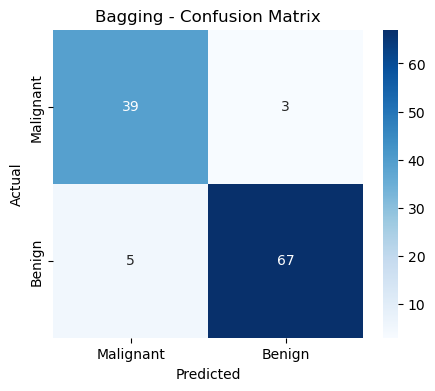

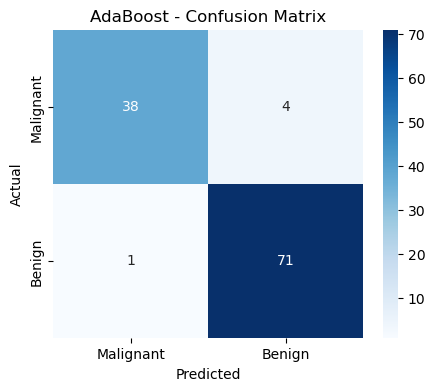

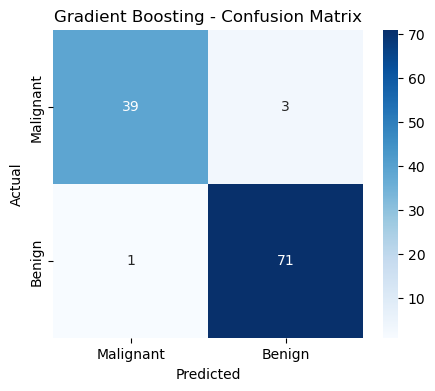

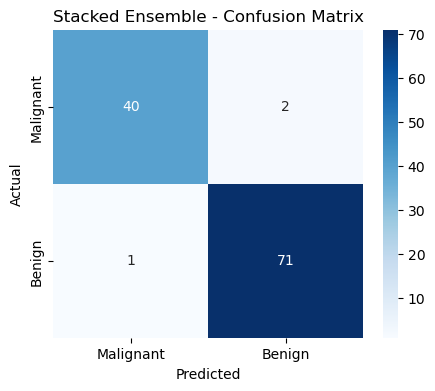

In [30]:
models_predictions = {
    "Bagging": bagging_pred,
    "AdaBoost": adaboost_pred,
    "Gradient Boosting": gradient_pred,
    "Stacked Ensemble": stacking_pred
}


for name, predictions in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Malignant",
            "Benign"
        ],
        yticklabels=[
            "Malignant",
            "Benign"
        ]
    )

    plt.title(
        name + " - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

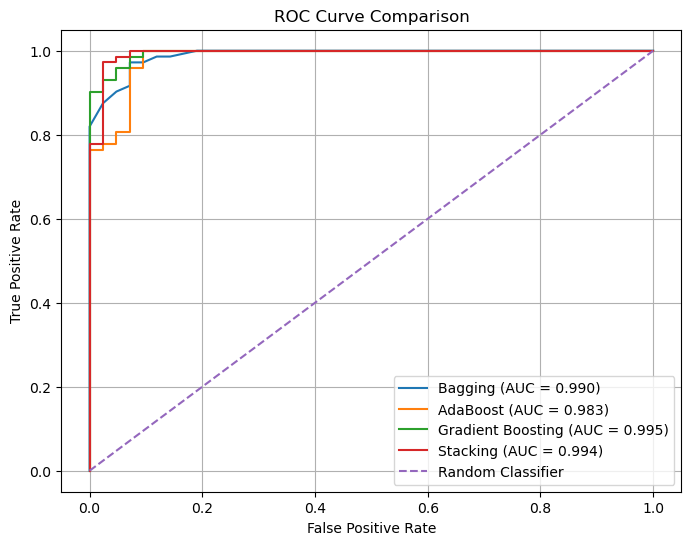

In [31]:
plt.figure(figsize=(8, 6))


# Bagging
fpr, tpr, _ = roc_curve(
    y_test,
    bagging_prob
)

auc = roc_auc_score(
    y_test,
    bagging_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"Bagging (AUC = {auc:.3f})"
)


# AdaBoost
fpr, tpr, _ = roc_curve(
    y_test,
    adaboost_prob
)

auc = roc_auc_score(
    y_test,
    adaboost_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"AdaBoost (AUC = {auc:.3f})"
)


# Gradient Boosting
fpr, tpr, _ = roc_curve(
    y_test,
    gradient_prob
)

auc = roc_auc_score(
    y_test,
    gradient_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {auc:.3f})"
)


# Stacking
fpr, tpr, _ = roc_curve(
    y_test,
    stacking_prob
)

auc = roc_auc_score(
    y_test,
    stacking_prob
)

plt.plot(
    fpr,
    tpr,
    label=f"Stacking (AUC = {auc:.3f})"
)


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid()

plt.show()

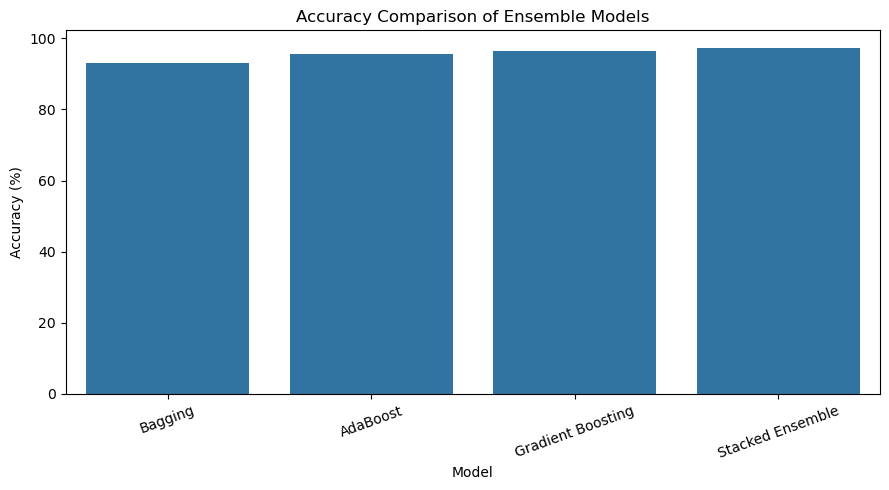

In [32]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy (%)"
)

plt.title(
    "Accuracy Comparison of Ensemble Models"
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

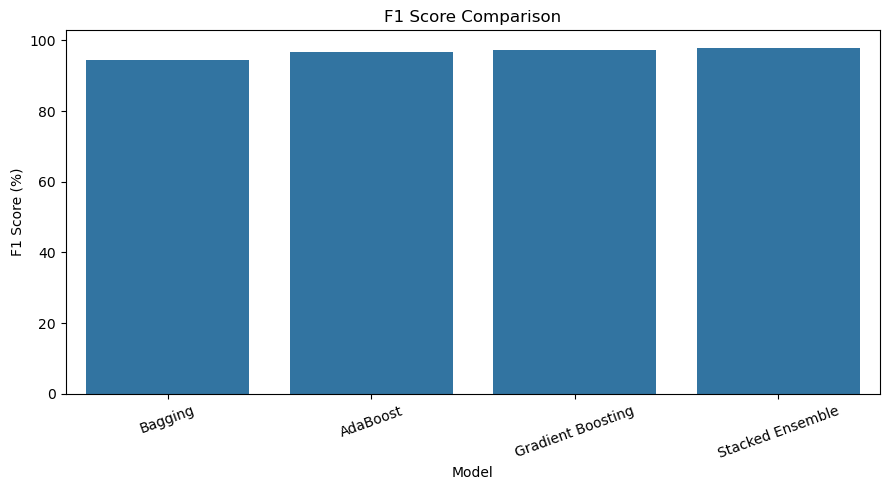

In [33]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1 Score (%)"
)

plt.title(
    "F1 Score Comparison"
)

plt.xlabel("Model")
plt.ylabel("F1 Score (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [34]:
best_model = comparison.loc[
    comparison["Accuracy (%)"].idxmax()
]

print("Best Model:", best_model["Model"])

print(
    "Accuracy:",
    round(best_model["Accuracy (%)"], 2),
    "%"
)

print(
    "Precision:",
    round(best_model["Precision (%)"], 2),
    "%"
)

print(
    "Recall:",
    round(best_model["Recall (%)"], 2),
    "%"
)

print(
    "F1 Score:",
    round(best_model["F1 Score (%)"], 2),
    "%"
)

print(
    "ROC-AUC:",
    round(best_model["ROC-AUC"], 3)
)

Best Model: Stacked Ensemble
Accuracy: 97.37 %
Precision: 97.26 %
Recall: 98.61 %
F1 Score: 97.93 %
ROC-AUC: 0.994
